<h1 style="color:blue;text-align:center;">Disease prediction using symptoms model</h1>

<h2 style="color:Red;">Importing required libraries</h1>

<h3 style="color:Purple;">For data preprocessing</h1>

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

<h3 style="color:Purple;">For data visualization</h1>

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

<h3 style="color:Purple;">For model training and evaluation</h1>

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix

<h3 style="color:Purple;">For saving model amnd label encode</h1>

In [4]:
import joblib as jb

In [5]:
data = pd.read_csv("Training.csv").dropna(axis = 1)
data.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


<h2 style="color:red;">Data Preprocessing</h1>

In [6]:
data.columns.values

array(['itching', 'skin_rash', 'nodal_skin_eruptions',
       'continuous_sneezing', 'shivering', 'chills', 'joint_pain',
       'stomach_pain', 'acidity', 'ulcers_on_tongue', 'muscle_wasting',
       'vomiting', 'burning_micturition', 'spotting_ urination',
       'fatigue', 'weight_gain', 'anxiety', 'cold_hands_and_feets',
       'mood_swings', 'weight_loss', 'restlessness', 'lethargy',
       'patches_in_throat', 'irregular_sugar_level', 'cough',
       'high_fever', 'sunken_eyes', 'breathlessness', 'sweating',
       'dehydration', 'indigestion', 'headache', 'yellowish_skin',
       'dark_urine', 'nausea', 'loss_of_appetite', 'pain_behind_the_eyes',
       'back_pain', 'constipation', 'abdominal_pain', 'diarrhoea',
       'mild_fever', 'yellow_urine', 'yellowing_of_eyes',
       'acute_liver_failure', 'fluid_overload', 'swelling_of_stomach',
       'swelled_lymph_nodes', 'malaise', 'blurred_and_distorted_vision',
       'phlegm', 'throat_irritation', 'redness_of_eyes', 'sinus_press

In [7]:
data.columns = data.columns.str.replace('_', ' ').str.title()  #Preparing columnn names
data["Prognosis"]=data["Prognosis"].str.title()
data.head()

,Itching,Skin Rash,Nodal Skin Eruptions,Continuous Sneezing,Shivering,Chills,Joint Pain,Stomach Pain,Acidity,Ulcers On Tongue,...,Blackheads,Scurring,Skin Peeling,Silver Like Dusting,Small Dents In Nails,Inflammatory Nails,Blister,Red Sore Around Nose,Yellow Crust Ooze,Prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal Infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal Infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal Infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal Infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal Infection


In [8]:
data[data["Fluid Overload"]==1]

,Itching,Skin Rash,Nodal Skin Eruptions,Continuous Sneezing,Shivering,Chills,Joint Pain,Stomach Pain,Acidity,Ulcers On Tongue,...,Blackheads,Scurring,Skin Peeling,Silver Like Dusting,Small Dents In Nails,Inflammatory Nails,Blister,Red Sore Around Nose,Yellow Crust Ooze,Prognosis


In [9]:
data.drop(columns=["Fluid Overload"],inplace=True)
data.rename(columns={"Fluid Overload.1":"Fluid Overload"},inplace=True)  #renaming a coulmn

<h3 style="color:purple;">Symtpoms for Disease Prediction</h1>

In [10]:
symptoms=data.columns.values
symptoms

array(['Itching', 'Skin Rash', 'Nodal Skin Eruptions',
       'Continuous Sneezing', 'Shivering', 'Chills', 'Joint Pain',
       'Stomach Pain', 'Acidity', 'Ulcers On Tongue', 'Muscle Wasting',
       'Vomiting', 'Burning Micturition', 'Spotting  Urination',
       'Fatigue', 'Weight Gain', 'Anxiety', 'Cold Hands And Feets',
       'Mood Swings', 'Weight Loss', 'Restlessness', 'Lethargy',
       'Patches In Throat', 'Irregular Sugar Level', 'Cough',
       'High Fever', 'Sunken Eyes', 'Breathlessness', 'Sweating',
       'Dehydration', 'Indigestion', 'Headache', 'Yellowish Skin',
       'Dark Urine', 'Nausea', 'Loss Of Appetite', 'Pain Behind The Eyes',
       'Back Pain', 'Constipation', 'Abdominal Pain', 'Diarrhoea',
       'Mild Fever', 'Yellow Urine', 'Yellowing Of Eyes',
       'Acute Liver Failure', 'Swelling Of Stomach',
       'Swelled Lymph Nodes', 'Malaise', 'Blurred And Distorted Vision',
       'Phlegm', 'Throat Irritation', 'Redness Of Eyes', 'Sinus Pressure',
       'Runn

<h3 style="color:purple;">Checking whether the dataset is balanced or not</h3>

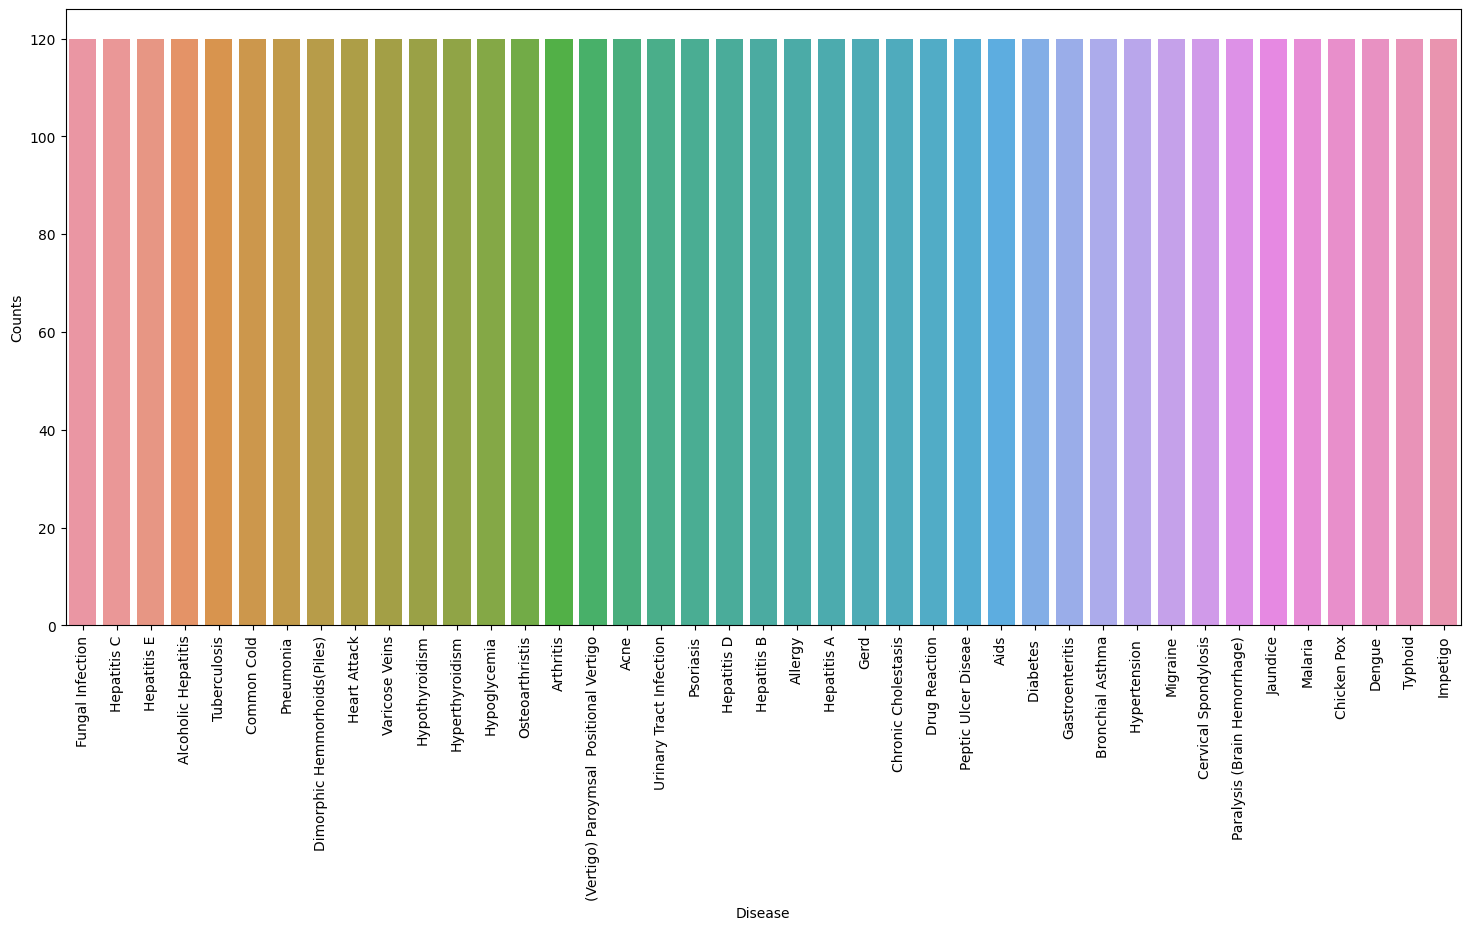

In [11]:

disease_counts = data["Prognosis"].value_counts()
temp_df = pd.DataFrame({
    "Disease": disease_counts.index,
    "Counts": disease_counts.values
})
 
plt.figure(figsize = (18,8))
sns.barplot(x = "Disease", y = "Counts", data = temp_df)
plt.xticks(rotation=90)
plt.show()

<h4 style="color:green;">Result : As we can see from above bar grap each disease has equal no. of sample data so our data is balanced</h3>



<h3 style="color:purple;">Encoding of our target column data to numerical data as it contains string data</h3>

In [12]:
# Encoding the target value into numerical value using LabelEncoder
encoder = LabelEncoder()
data["Prognosis"] = encoder.fit_transform(data["Prognosis"])

#Saving for use with api
jb.dump(encoder,'labelEncoder.pkl')


['labelEncoder.pkl']

In [13]:
data.Prognosis.values

array([15, 15, 15, ..., 39, 36, 28])

<h1 style="color:red;">Training and Evaluating ML model</h3>

<h3 style="color:purple;">Evaluating performance of each model using K-Fold Cross Validation</h3>

In [14]:
X = data.iloc[:,:-1]
y = data.iloc[:, -1]

models = {
	"SVC":SVC(),
	"Gaussian NB":BernoulliNB(),
	"Random Forest":RandomForestClassifier(random_state=18)
}

for model_name in models:
	model = models[model_name]
	scores = cross_val_score(model, X, y, cv = 10)
	print("=="*30)
	print(model_name)
	print(f"Scores: {scores*100}")
	print(f"Mean Score: {np.mean(scores)*100}%")

SVC
Scores: [100. 100. 100. 100. 100. 100. 100. 100. 100. 100.]
Mean Score: 100.0%
Gaussian NB
Scores: [100. 100. 100. 100. 100. 100. 100. 100. 100. 100.]
Mean Score: 100.0%
Random Forest
Scores: [100. 100. 100. 100. 100. 100. 100. 100. 100. 100.]
Mean Score: 100.0%


<h3 style="color:purple;">Splitting dataset in traning and test dataset</h3>

In [15]:
X_train, X_test, y_train, y_test =train_test_split(
X, y, test_size = 0.2, random_state = 24)

print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Test: {X_test.shape}, {y_test.shape}")


Train: (3936, 131), (3936,)
Test: (984, 131), (984,)


<h3 style="color:purple;">Evaluating Performance of all models with visualization</h3>

In [16]:
def printConfusionMatrix(y_test,preds,Title):
    cf_matrix = confusion_matrix(y_test, preds)
    plt.figure(figsize=(8,8))
    sns.heatmap(cf_matrix, annot=True)
    plt.title(Title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


Accuracy on train data by SVM Classifier: 100.0


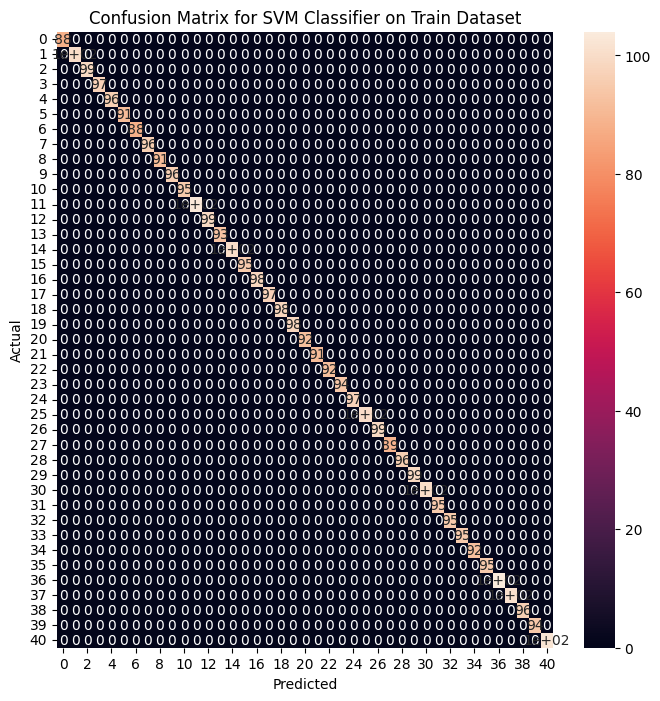

Accuracy on test data by SVM Classifier: 100.0


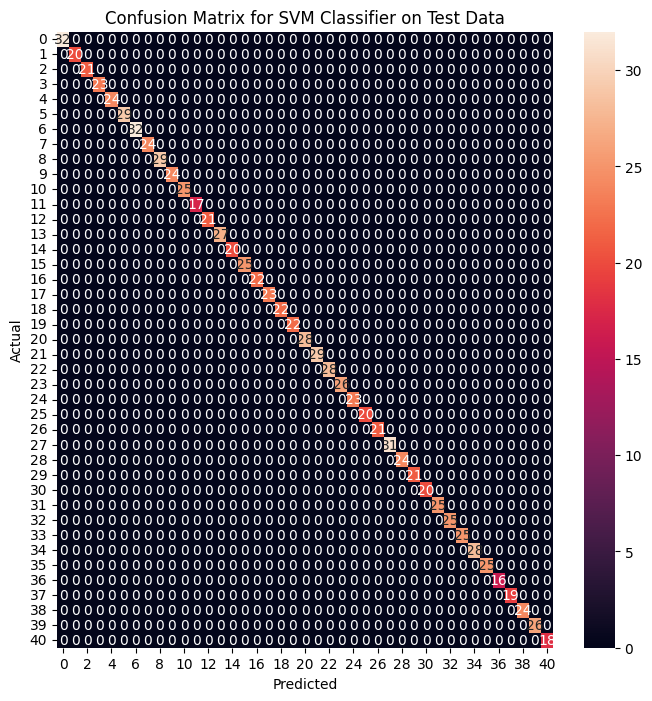

Accuracy on train data by Naive Bayes Classifier: 100.0


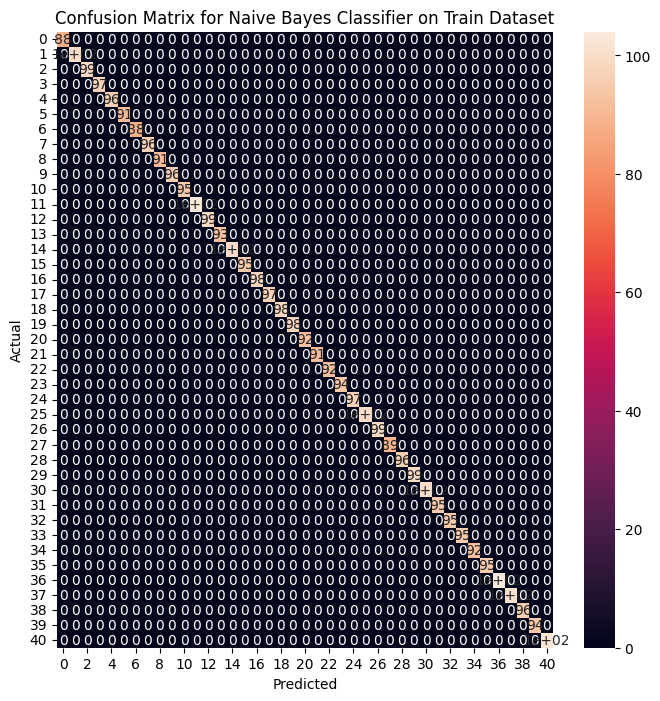

Accuracy on test data by Naive Bayes Classifier: 100.0


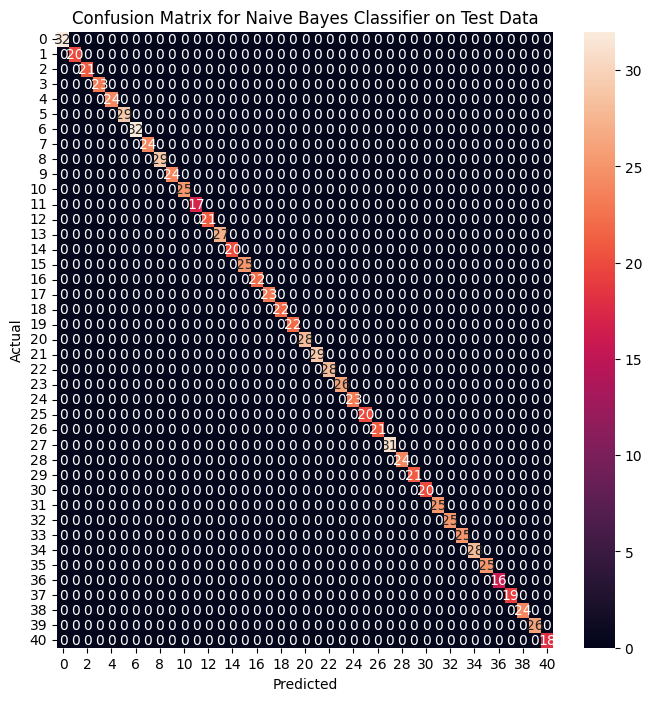

Accuracy on train data by Random Forest Classifier: 100.0


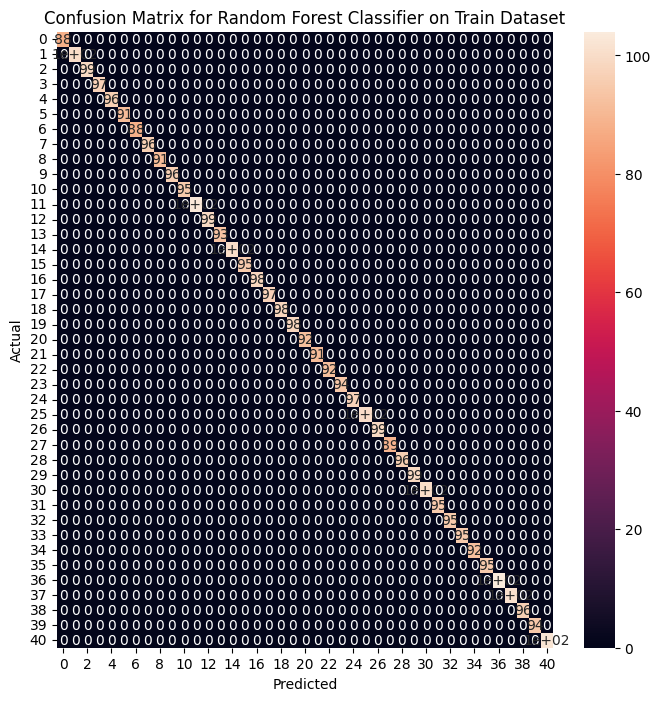

Accuracy on test data by Random Forest Classifier: 100.0


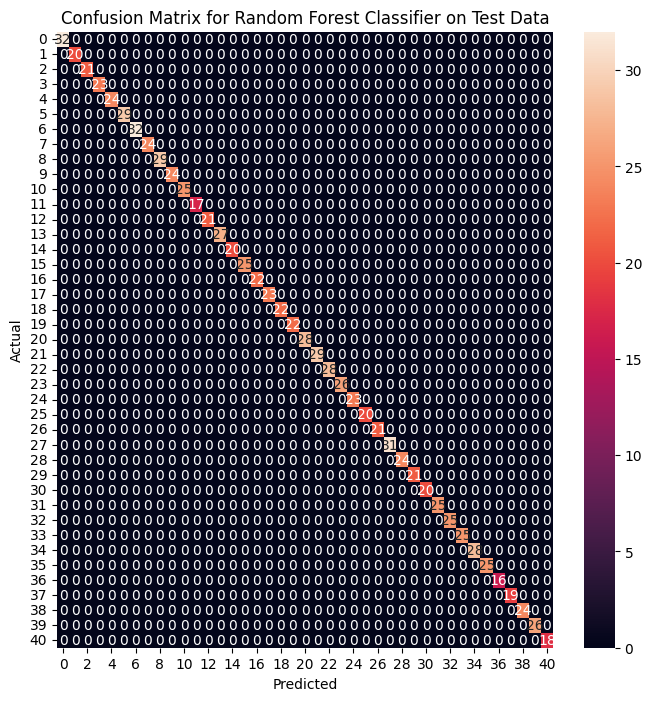

In [24]:
# Training and testing SVM Classifier
svm_model = SVC()
svm_model.fit(X_train, y_train)
preds = svm_model.predict(X_test)

print(f"Accuracy on train data by SVM Classifier: {accuracy_score(y_train, svm_model.predict(X_train))*100}")
printConfusionMatrix(y_train, svm_model.predict(X_train),"Confusion Matrix for SVM Classifier on Train Dataset")
print(f"Accuracy on test data by SVM Classifier: {accuracy_score(y_test, preds)*100}")

printConfusionMatrix(y_test,preds,"Confusion Matrix for SVM Classifier on Test Data")



# Training and testing Naive Bayes Classifier
nb_model = BernoulliNB()
nb_model.fit(X_train, y_train)
preds = nb_model.predict(X_test)
print(f"Accuracy on train data by Naive Bayes Classifier: {accuracy_score(y_train, nb_model.predict(X_train))*100}")
printConfusionMatrix(y_train, nb_model.predict(X_train),"Confusion Matrix for Naive Bayes Classifier on Train Dataset")
print(f"Accuracy on test data by Naive Bayes Classifier: {accuracy_score(y_test, preds)*100}")

printConfusionMatrix(y_test, preds,"Confusion Matrix for Naive Bayes Classifier on Test Data")


# Training and testing Random Forest Classifier
rf_model = RandomForestClassifier(random_state=18)
rf_model.fit(X_train, y_train)
preds = rf_model.predict(X_test)
print(f"Accuracy on train data by Random Forest Classifier: {accuracy_score(y_train, rf_model.predict(X_train))*100}")
printConfusionMatrix(y_train, rf_model.predict(X_train),"Confusion Matrix for Random Forest Classifier on Train Dataset")
print(f"Accuracy on test data by Random Forest Classifier: {accuracy_score(y_test, preds)*100}")

printConfusionMatrix(y_test, preds,"Confusion Matrix for Random Forest Classifier on Test Data")




<h3 style="color:purple;">Training the models on whole data</h3>

In [18]:
final_svm_model = SVC()
final_nb_model = BernoulliNB()
final_rf_model = RandomForestClassifier(random_state=18)
final_svm_model.fit(X, y)
final_nb_model.fit(X, y)
final_rf_model.fit(X, y)

RandomForestClassifier(random_state=18)

<h3 style="color:purple;">Evaluationg performace of combined model (Ensemble approach) with visulaisation</h3>

In [19]:
from statistics import mode,StatisticsError


# Reading the test data
test_data = pd.read_csv("Testing.csv").dropna(axis=1)


test_data.columns=test_data.columns.str.replace('_', ' ').str.title()
test_data["Prognosis"]=test_data["Prognosis"].str.title()

test_data.drop(columns={"Fluid Overload"},inplace=True)
test_data.rename(columns={"Fluid Overload.1":"Fluid Overload"},inplace=True)



test_X = test_data.iloc[:, :-1]
test_Y = encoder.transform(test_data.iloc[:, -1])

# Making prediction by all classifier models for prediction
svm_preds = final_svm_model.predict(test_X)
nb_preds = final_nb_model.predict(test_X)
rf_preds = final_rf_model.predict(test_X)


#Taking mode of prediction of all classifiers
final_preds=[]

for preds in zip(svm_preds, nb_preds, rf_preds):
    try:
        final_preds.append(mode(preds))
    except StatisticsError:
        final_preds.append(preds[2])  #if there is no mode,take value of Random forest as prediction

print(final_preds)

[15, 4, 17, 9, 14, 34, 2, 12, 16, 6, 24, 31, 7, 33, 29, 30, 8, 11, 38, 19, 20, 21, 22, 23, 3, 37, 10, 35, 13, 18, 40, 27, 25, 26, 32, 5, 0, 1, 39, 36, 28, 15]


<h4 style="color:green;">Above are the predictions made by taking mode (ensemble approach) </h3>

<h3 style="color:purple;">Saving models for using with API</h3>

Accuracy on Test dataset by the combined model: 100.0


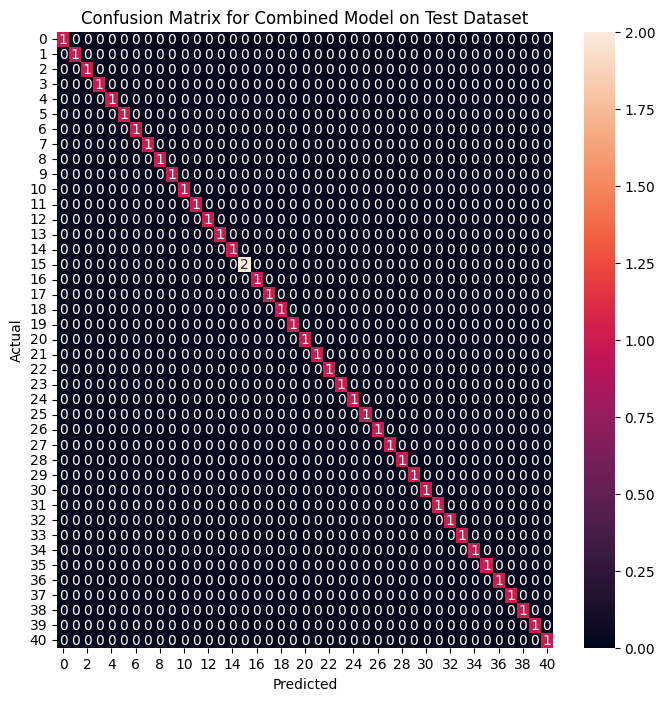

In [20]:
print(f"Accuracy on Test dataset by the combined model: {accuracy_score(test_Y, final_preds)*100}")

printConfusionMatrix(test_Y, final_preds,"Confusion Matrix for Combined Model on Test Dataset")


<h3 style="color:purple;">Saving models for using with API</h3>

In [21]:
jb.dump(final_svm_model,'SVM_Model.pkl')
jb.dump(final_nb_model,'NaiveB_Model.pkl')
jb.dump(final_rf_model,'RandomForest_Model.pkl')

['RandomForest_Model.pkl']

<h2 style="color:red;">Testing model with new unknown data by user</h2>

In [22]:
X.columns.values

array(['Itching', 'Skin Rash', 'Nodal Skin Eruptions',
       'Continuous Sneezing', 'Shivering', 'Chills', 'Joint Pain',
       'Stomach Pain', 'Acidity', 'Ulcers On Tongue', 'Muscle Wasting',
       'Vomiting', 'Burning Micturition', 'Spotting  Urination',
       'Fatigue', 'Weight Gain', 'Anxiety', 'Cold Hands And Feets',
       'Mood Swings', 'Weight Loss', 'Restlessness', 'Lethargy',
       'Patches In Throat', 'Irregular Sugar Level', 'Cough',
       'High Fever', 'Sunken Eyes', 'Breathlessness', 'Sweating',
       'Dehydration', 'Indigestion', 'Headache', 'Yellowish Skin',
       'Dark Urine', 'Nausea', 'Loss Of Appetite', 'Pain Behind The Eyes',
       'Back Pain', 'Constipation', 'Abdominal Pain', 'Diarrhoea',
       'Mild Fever', 'Yellow Urine', 'Yellowing Of Eyes',
       'Acute Liver Failure', 'Swelling Of Stomach',
       'Swelled Lymph Nodes', 'Malaise', 'Blurred And Distorted Vision',
       'Phlegm', 'Throat Irritation', 'Redness Of Eyes', 'Sinus Pressure',
       'Runn

In [23]:
import warnings
from statistics import mode, StatisticsError
import numpy as np

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# Assuming 'X', 'encoder', 'final_rf_model', 'final_nb_model', and 'final_svm_model' are defined elsewhere
symptoms = X.columns.values

# Creating a symptom index dictionary to encode the
# input symptoms into numerical form
symptom_index = {}
for index, value in enumerate(symptoms):
    symptom = " ".join([i for i in value.split(" ")])
    symptom_index[symptom] = index

data_dict = {
    "symptom_index": symptom_index,
    "predictions_classes": encoder.classes_
}

# Defining the Function
# Input: string containing symptoms separated by commas
# Output: Generated predictions by models
def predictDisease(symptoms):
    symptoms = symptoms.split(",")

    # creating input data for the models
    input_data = [0] * len(data_dict["symptom_index"])
    for symptom in symptoms:
        index = data_dict["symptom_index"][symptom]
        input_data[index] = 1

    # reshaping the input data and converting it
    # into a suitable format for model predictions
    input_data = np.array(input_data).reshape(1, -1)

    # generating individual outputs
    rf_prediction = data_dict["predictions_classes"][final_rf_model.predict(input_data)[0]]
    nb_prediction = data_dict["predictions_classes"][final_nb_model.predict(input_data)[0]]
    svm_prediction = data_dict["predictions_classes"][final_svm_model.predict(input_data)[0]]

    # making final prediction by taking mode of all predictions
    try:
        final_prediction = mode([rf_prediction, nb_prediction, svm_prediction])
    except StatisticsError:
        final_prediction = rf_prediction

    predictions = {
        "rf_model_prediction": rf_prediction,
        "naive_bayes_prediction": nb_prediction,
        "svm_model_prediction": svm_prediction,
        "final_prediction": final_prediction
    }
    return predictions

# Testing the function
print(predictDisease("Itching,Skin Rash,Nodal Skin Eruptions"))


{'rf_model_prediction': 'Fungal Infection', 'naive_bayes_prediction': 'Fungal Infection', 'svm_model_prediction': 'Fungal Infection', 'final_prediction': 'Fungal Infection'}
